In [1]:
import torch
import gc

def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()

clear_gpu()

In [2]:
import os
import time
import random
import pickle
import warnings
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch_geometric.nn import ChebConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device detectat: {device}")

CSV_PATH = "PEMS-BAY.csv"
ADJ_PATH = "Rezultate/adj_mx_bay.pkl"
os.makedirs("Rezultate", exist_ok=True)

# ÎNCĂRCARE GRAF
with open(ADJ_PATH, "rb") as f:
    _, _, adj_mx = pickle.load(f)

adj_sparse = adj_mx > 0
edge_index = torch.tensor(np.array(np.where(adj_sparse)), dtype=torch.long).to(device)
edge_weight = torch.tensor(adj_mx[adj_sparse], dtype=torch.float32).to(device)

# Construirea secvențelor de intrare folosind o fereastră temporală
def build_dataset(data, lookback=12): 
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

print("Se încarcă datele...")
df = pd.read_csv(CSV_PATH).dropna()
data = df.iloc[:, 1:].values.astype(np.float32)

LOOKBACK = 12
X, y = build_dataset(data, LOOKBACK)

# Împărțirea datelor în seturi de antrenare, validare și testare
n_samples = len(X)
train_end = int(0.70 * n_samples)
val_end = int(0.85 * n_samples)

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]

# Normalizarea datelor
n_nodes = X_train.shape[2]
scaler_X = MinMaxScaler()
X_train_s = scaler_X.fit_transform(X_train.reshape(-1, n_nodes)).reshape(X_train.shape)
X_val_s   = scaler_X.transform(X_val.reshape(-1, n_nodes)).reshape(X_val.shape)
X_test_s  = scaler_X.transform(X_test.reshape(-1, n_nodes)).reshape(X_test.shape)

scaler_y = MinMaxScaler()
y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

# Conversia datelor în tensori PyTorch
X_train_t = torch.tensor(X_train_s, dtype=torch.float32).unsqueeze(-1)
X_val_t   = torch.tensor(X_val_s, dtype=torch.float32).unsqueeze(-1)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32).unsqueeze(-1)

y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
y_val_t   = torch.tensor(y_val_s, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_s, dtype=torch.float32)


Device detectat: cuda
Se încarcă datele...


In [3]:
class STGCN_Attention(nn.Module):
    def __init__(self, num_nodes, in_channels=1, hidden_channels=64, K=3, heads=4, dropout=0.2):
        super(STGCN_Attention, self).__init__()
        # Prima convoluție temporală
        self.t_conv1 = nn.Conv2d(in_channels, hidden_channels, kernel_size=(3, 1))
        # Convoluție pe graf
        self.gcn = ChebConv(hidden_channels, hidden_channels, K=K)
        # Mecanism de atenție temporală
        self.attention = nn.MultiheadAttention(
            embed_dim=hidden_channels,
            num_heads=heads,
            dropout=dropout,
            batch_first=True
        )
        self.norm = nn.LayerNorm(hidden_channels)
        # A doua convoluție temporală
        self.t_conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size=(3, 1))
        self.dropout = nn.Dropout(dropout)
        # Strat complet conectat pentru predicția finală
        self.fc = nn.Linear(hidden_channels * 8, 1)

    def forward(self, x, edge_index, edge_weight):
        # Reordonarea dimensiunilor pentru Conv2D
        x = x.permute(0, 3, 1, 2)
        # Extragerea caracteristicilor temporale
        x = torch.relu(self.t_conv1(x))
        b, c, t, n = x.shape
        # Agregarea informației spațiale folosind graful
        x_gcn = x.permute(0, 2, 3, 1).reshape(-1, c)
        x_gcn = torch.relu(self.gcn(x_gcn, edge_index, edge_weight))
        x_gcn = x_gcn.reshape(b, t, n, c)
        # Aplicarea atenției pentru fiecare nod
        x_att = x_gcn.permute(0, 2, 1, 3).reshape(b * n, t, c)
        attn_out, _ = self.attention(x_att, x_att, x_att)
        x_att = self.norm(x_att + attn_out)
        # Revenirea la forma necesară convoluției temporale
        x_att = x_att.reshape(b, n, t, c).permute(0, 3, 2, 1)
        # Extragerea caracteristicilor temporale finale
        x = torch.relu(self.t_conv2(x_att))
        # Pregătirea pentru stratul complet conectat
        x = x.permute(0, 3, 2, 1).reshape(b, n, -1)
        x = self.dropout(x)
        out = self.fc(x)
        return out.squeeze(-1)

In [4]:
def train_model(model, train_loader, val_loader, lr, edge_index, edge_weight, epochs=50):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    for epoch in range(epochs):
        model.train()
        t_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            optimizer.zero_grad()
            out = model(xb, edge_index, edge_weight)
            loss = criterion(out, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item()
            
        model.eval()
        v_loss = 0
        with torch.no_grad():
            for xv, yv in val_loader:
                xv, yv = xv.to(device, non_blocking=True), yv.to(device, non_blocking=True)
                v_loss += criterion(model(xv, edge_index, edge_weight), yv).item()
                
        train_loss_avg = t_loss / len(train_loader)
        val_loss_avg = v_loss / len(val_loader)
        print(f" Epoca {epoch+1:2d}/{epochs} | Train Loss: {train_loss_avg:.6f} | Val Loss: {val_loss_avg:.6f}")
                
    return model

In [5]:
def fitness_stgcn_attention(params, edge_index, edge_weight):
    raw_channels = int(round(params[0]))
    h_channels = ((raw_channels + 3) // 4) * 4 
    lr_val = 10**params[1]
    dropout_val = np.clip(10**params[2], 0.0, 0.4)
    batch_options = [16, 32, 64]
    idx = int(np.clip(round(params[3]), 0, len(batch_options) - 1))
    batch_val = batch_options[idx]
    
    try:
        train_loader_tmp = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_val, shuffle=True, pin_memory=True)
        val_loader_tmp   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_val, shuffle=False, pin_memory=True)
        
        model_tmp = STGCN_Attention(
            num_nodes=325, 
            in_channels=1, 
            hidden_channels=h_channels, 
            K=3,
            heads=4,
            dropout=dropout_val
        ).to(device)
        
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model_tmp.parameters(), lr=lr_val)
        
        for epoch in range(10): 
            model_tmp.train()
            for xb, yb in train_loader_tmp:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                optimizer.zero_grad()
                pred = model_tmp(xb, edge_index, edge_weight)
                loss = criterion(pred, yb)
                if torch.isnan(loss):
                    return 1e6
                    
                loss.backward()
                nn.utils.clip_grad_norm_(model_tmp.parameters(), 1.0)
                optimizer.step()
                
        model_tmp.eval()
        val_loss_total = 0
        with torch.no_grad():
            for xv, yv in val_loader_tmp:
                xv, yv = xv.to(device, non_blocking=True), yv.to(device, non_blocking=True)
                v_pred = model_tmp(xv, edge_index, edge_weight)
                val_loss_total += criterion(v_pred, yv).item()
                
        return val_loss_total / len(val_loader_tmp)

    except Exception:
        return 1e6
    finally:
        if 'model_tmp' in locals():
            del model_tmp
        torch.cuda.empty_cache()

In [6]:
class PSO_Hyper:
    def __init__(self, func, population=10, max_iter=5):
        self.func = func
        self.dim = 4  
        self.population = population
        self.max_iter = max_iter
        self.lb = np.array([24, -4.0, -3.0, 0.0])
        self.ub = np.array([64, -2.0, -0.4, 2.99]) 
        self.v_max = (self.ub - self.lb) * 0.2
        self.positions = np.random.uniform(self.lb, self.ub, (population, self.dim))
        self.velocities = np.zeros((population, self.dim))
        self.pbest = self.positions.copy()
        self.cache = {}
        self.pbest_val = np.array([self.evaluate(p) for p in self.positions])
        best_idx = np.argmin(self.pbest_val)
        self.gbest = self.pbest[best_idx].copy()
        self.gbest_val = self.pbest_val[best_idx]
        self.history = []

    def evaluate(self, p):
        key = tuple(np.round(p, 4))
        if key in self.cache:
            return self.cache[key]
        try:
            val = self.func(p)
            if np.isnan(val) or val > 1e6:
                val = 1e6
        except:
            val = 1e6
        self.cache[key] = val
        return val

    def optimize(self):
        c1, c2 = 1.5, 1.5
        
        for it in range(self.max_iter):
            w = 0.9 - (0.5 * (it / self.max_iter)) 
            
            for i in range(self.population):
                r1, r2 = np.random.rand(self.dim), np.random.rand(self.dim)
                
                self.velocities[i] = (
                    w * self.velocities[i]
                    + c1 * r1 * (self.pbest[i] - self.positions[i])
                    + c2 * r2 * (self.gbest - self.positions[i])
                )
                self.velocities[i] = np.clip(self.velocities[i], -self.v_max, self.v_max)
                
                # Actualizare poziție particulă
                self.positions[i] += self.velocities[i]
                self.positions[i] = np.clip(self.positions[i], self.lb, self.ub)

                fit = self.evaluate(self.positions[i])
                
                # Actualizare pbest (local optim)
                if fit < self.pbest_val[i]:
                    self.pbest[i] = self.positions[i].copy()
                    self.pbest_val[i] = fit

                # Actualizare gbest (global optim)
                if fit < self.gbest_val:
                    self.gbest = self.positions[i].copy()
                    self.gbest_val = fit
                    
            self.history.append(self.gbest_val)
            
            best_channels_raw = int(round(self.gbest[0]))
            best_channels = ((best_channels_raw + 3) // 4) * 4
            best_lr = 10 ** self.gbest[1]
            best_dropout = np.clip(10 ** self.gbest[2], 0.0, 0.4)
            batch_options = [16, 32, 64]
            best_batch_idx = int(np.clip(round(self.gbest[3]), 0, len(batch_options) - 1))
            best_batch = batch_options[best_batch_idx]
            
            print(f" PSO Iter {it+1:2d}/{self.max_iter} | Best Cost: {self.gbest_val:.6f} | "
                  f"Channels: {best_channels} | LR: {best_lr:.6f} | Dropout: {best_dropout:.4f} | Batch: {best_batch}")
            
        return self.gbest, self.gbest_val, self.history

In [7]:
#  RULARE OPTIMIZARE WOA

print("\n Pornesc Optimizarea PSO pentru STGCN-Attention...")
start_pso = time.time()
torch.cuda.empty_cache()

pso = PSO_Hyper(func=lambda p: fitness_stgcn_attention(p, edge_index, edge_weight), population=10, max_iter=5)
best_params, best_cost, *_ = pso.optimize()

print(f" Optimizarea PSO completă în {(time.time() - start_pso)/60:.2f} minute.")

h_channels_raw = int(round(best_params[0]))
h_channels_opt = ((h_channels_raw + 3) // 4) * 4
lr_opt = 10 ** best_params[1]
dropout_opt = np.clip(10 ** best_params[2], 0.0, 0.4)
batch_options = [16, 32, 64]
batch_opt = batch_options[int(np.clip(round(best_params[3]), 0, len(batch_options) - 1))]

print("\n PARAMETRI OPTIMI REZULTAȚI:")
print(f"   Canale (Hidden): {h_channels_opt}")
print(f"   Learning Rate:   {lr_opt:.6f}")
print(f"   Dropout:         {dropout_opt:.4f}")
print(f"   Batch Size:      {batch_opt}")


# ANTRENARE MODEL FINAL

print(f"\n Începe antrenarea modelului final cu parametrii optimi ...")
start_final_train = time.time()

train_loader_final = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_opt, shuffle=True, pin_memory=True)
val_loader_final   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_opt, shuffle=False, pin_memory=True)

model_final = STGCN_Attention(
    num_nodes=325, 
    in_channels=1, 
    hidden_channels=h_channels_opt, 
    K=3,
    heads=4,
    dropout=dropout_opt
).to(device)

model_final = train_model(
    model=model_final,
    train_loader=train_loader_final,
    val_loader=val_loader_final,
    lr=lr_opt,
    edge_index=edge_index,
    edge_weight=edge_weight,
    epochs=50
)
print(f" Antrenare finală completată în {(time.time() - start_final_train)/60:.2f} minute.")


 Pornesc Optimizarea PSO pentru STGCN-Attention...
 PSO Iter  1/5 | Best Cost: 0.000745 | Channels: 48 | LR: 0.002607 | Dropout: 0.0011 | Batch: 64
 PSO Iter  2/5 | Best Cost: 0.000745 | Channels: 48 | LR: 0.002607 | Dropout: 0.0011 | Batch: 64
 PSO Iter  3/5 | Best Cost: 0.000745 | Channels: 48 | LR: 0.002607 | Dropout: 0.0011 | Batch: 64
 PSO Iter  4/5 | Best Cost: 0.000745 | Channels: 48 | LR: 0.002607 | Dropout: 0.0011 | Batch: 64
 PSO Iter  5/5 | Best Cost: 0.000745 | Channels: 48 | LR: 0.002607 | Dropout: 0.0011 | Batch: 64
 Optimizarea PSO completă în 302.07 minute.

 PARAMETRI OPTIMI REZULTAȚI:
   Canale (Hidden): 48
   Learning Rate:   0.002607
   Dropout:         0.0011
   Batch Size:      64

 Începe antrenarea modelului final cu parametrii optimi ...
 Epoca  1/50 | Train Loss: 0.003885 | Val Loss: 0.000890
 Epoca  2/50 | Train Loss: 0.000765 | Val Loss: 0.000812
 Epoca  3/50 | Train Loss: 0.000726 | Val Loss: 0.000776
 Epoca  4/50 | Train Loss: 0.000706 | Val Loss: 0.00079

In [8]:
#  EVALUARE FINALĂ 
print("\n Evaluare pe setul de test...")
model_final.eval()
all_preds = []

test_loader_final = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_opt, shuffle=False, pin_memory=True)

with torch.no_grad():
    for xt, _ in test_loader_final:
        xt = xt.to(device, non_blocking=True)
        pred = model_final(xt, edge_index, edge_weight)
        all_preds.append(pred.cpu())

pred_test = torch.cat(all_preds, dim=0).numpy()

y_pred_inv = scaler_y.inverse_transform(pred_test)
y_real_inv = scaler_y.inverse_transform(y_test_s)

mse = mean_squared_error(y_real_inv, y_pred_inv)
mae = mean_absolute_error(y_real_inv, y_pred_inv)
rmse = np.sqrt(mse)
r2 = r2_score(y_real_inv, y_pred_inv)
var_ratio = np.var(y_pred_inv) / np.var(y_real_inv)

print("\n REZULTATE FINALE STGCN-ATTENTION-WOA:")
print(f"  MSE  : {mse:.4f}")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R2   : {r2:.4f}")
print(f"  Var  : {var_ratio:.4f}")


results = {
    "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
    "model": "STGCN-Attention-PSO",
    "version": "v5",
    "lookback": LOOKBACK,
    "gcn_channels": h_channels_opt,
    "learning_rate": f"{lr_opt:.6f}",
    "dropout": f"{dropout_opt:.4f}",
    "batch_size": batch_opt,
    "epochs": 50,
    "MSE": f"{mse:.6f}",
    "RMSE": f"{rmse:.4f}",
    "MAE": f"{mae:.4f}",
    "R2": f"{r2:.4f}",
    "Var_Ratio": f"{var_ratio:.4f}"
}

results_path = "Rezultate/log_experimente.csv"
pd.DataFrame([results]).to_csv(
    results_path,
    mode='a',
    header=not os.path.exists(results_path),
    index=False
)

np.save("Rezultate/preds_STGCN_Attention_PSO_V5.npy", y_pred_inv)
print(f"\n Rezultatele și predicțiile au fost salvate în '{results_path}'!")


 Evaluare pe setul de test...

 REZULTATE FINALE STGCN-ATTENTION-WOA:
  MSE  : 3.1721
  MAE  : 0.9425
  RMSE : 1.7811
  R2   : 0.9366
  Var  : 0.9797

 Rezultatele și predicțiile au fost salvate în 'Rezultate/log_experimente.csv'!


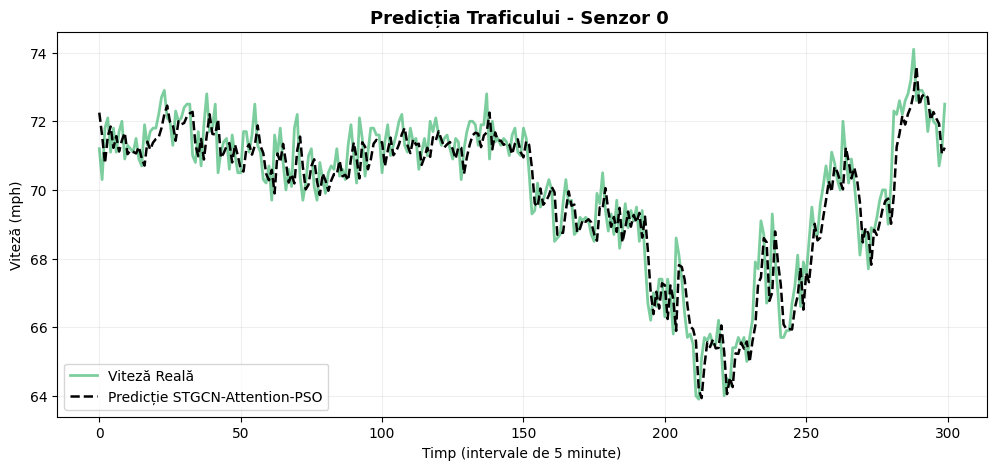

[INFO] Generez analiza comparativă Senzor Bun vs Senzor Slab...


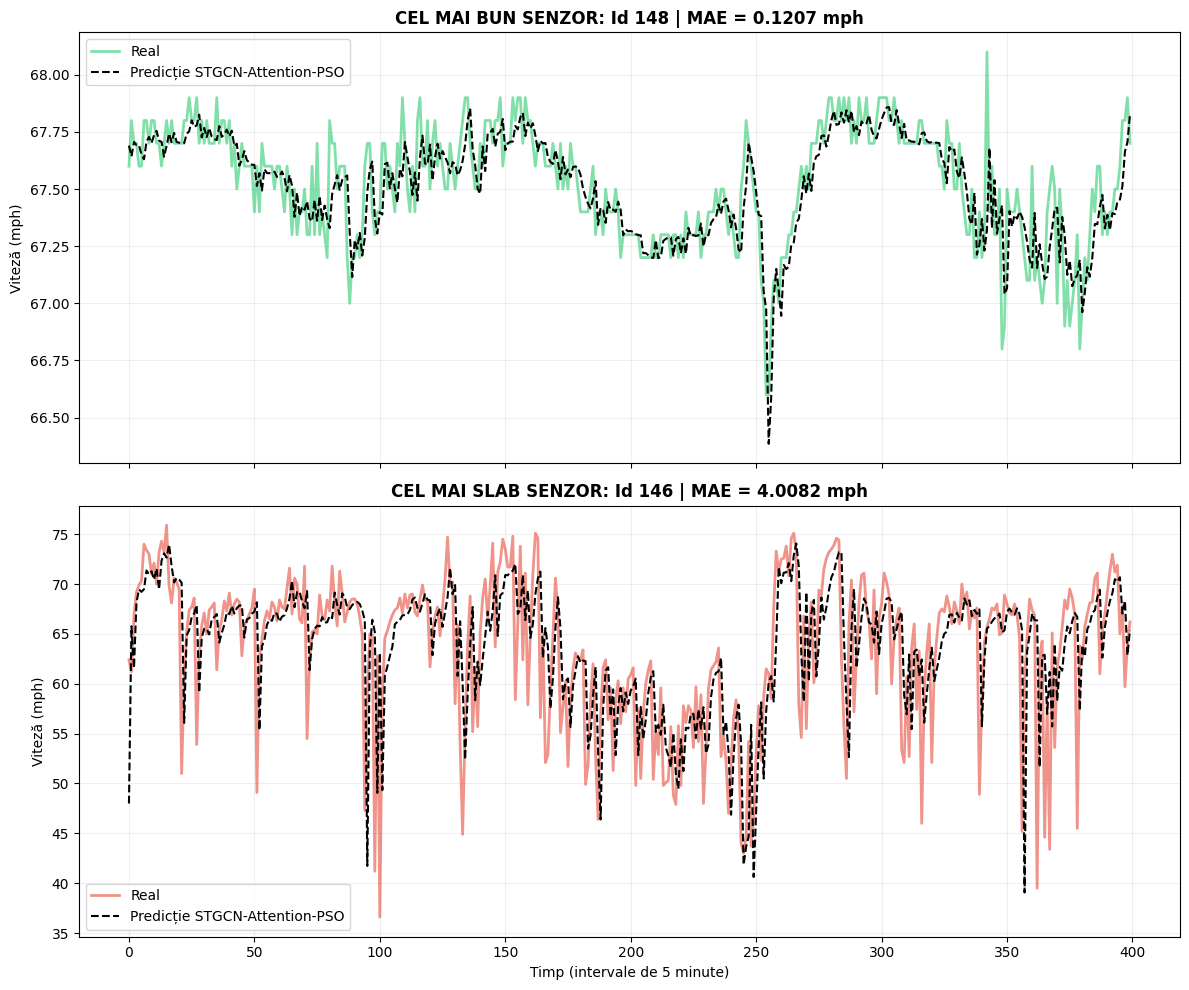

 Toate vizualizările au fost generate și salvate cu succes în folderul 'Rezultate'!


In [9]:
#Grafice predictii

os.makedirs("Rezultate", exist_ok=True)

# Comparația dintre valorile reale și predicții

plt.figure(figsize=(12, 5))

plt.plot(
    y_real_inv[:300, 0],
    label="Viteză Reală",
    color='#27ae60',
    alpha=0.6,
    linewidth=2
)

plt.plot(
    y_pred_inv[:300, 0],
    '--',
    label="Predicție STGCN-Attention-PSO",
    color='black',
    linewidth=1.8
)

plt.title(
    "Predicția Traficului - Senzor 0 ",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel("Viteză (mph)")
plt.xlabel("Timp (intervale de 5 minute)")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.2)

plt.savefig("Rezultate/Predictie_Senzor_0_STGCN_PSO_Attention2.png", dpi=300, bbox_inches='tight')
plt.show()


# Identificarea senzorilor cu cea mai bună și cea mai slabă performanță

mae_per_sensor = np.mean(np.abs(y_real_inv - y_pred_inv), axis=0)

best_s = np.argmin(mae_per_sensor)
worst_s = np.argmax(mae_per_sensor)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# BEST SENSOR
ax1.plot(
    y_real_inv[:400, best_s],
    label="Real",
    color='#2ecc71',
    alpha=0.6,
    linewidth=2
)

ax1.plot(
    y_pred_inv[:400, best_s],
    '--',
    label="Predicție STGCN-Attention-PSO",
    color='black',
    linewidth=1.5
)

ax1.set_title(
    f"CEL MAI BUN SENZOR: Id {best_s} | MAE = {mae_per_sensor[best_s]:.4f} mph",
    fontsize=12,
    fontweight='bold'
)
ax1.set_ylabel("Viteză (mph)")
ax1.legend()
ax1.grid(True, alpha=0.2)

# WORST SENSOR
ax2.plot(
    y_real_inv[:400, worst_s],
    label="Real",
    color='#e74c3c',
    alpha=0.6,
    linewidth=2
)

ax2.plot(
    y_pred_inv[:400, worst_s],
    '--',
    label="Predicție STGCN-Attention-PSO",
    color='black',
    linewidth=1.5
)

ax2.set_title(
    f"CEL MAI SLAB SENZOR: Id {worst_s} | MAE = {mae_per_sensor[worst_s]:.4f} mph",
    fontsize=12,
    fontweight='bold'
)
ax2.set_ylabel("Viteză (mph)")
ax2.set_xlabel("Timp (intervale de 5 minute)")
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("Rezultate/Analiza_Senzori_STGCN_Att_PSO.png", dpi=300, bbox_inches='tight')
plt.show()
